# 🧭 Sequential Boundary Classifiers for Colonoscopy Localization
### VIM Polyp Dataset · Adjacent-Segment Binary Classifiers

**Idea:** Instead of a single multi-class model that tries to classify *all* colon
segments at once, train a **separate binary classifier for each pair of
anatomically adjacent segments** (e.g. `cecum vs ascending`, `ascending vs
transverse`, `transverse vs descending`, ...).

During a real colonoscopy withdrawal, the scope moves through the colon in a
(mostly) fixed anatomical order. A bank of "boundary detectors" — one per
adjacent pair — can each specialize in telling two *neighboring* segments
apart, which is usually an easier problem than telling all segments apart at
once (neighboring segments tend to look more visually similar to each other
than to segments elsewhere in the colon, so a model that only has to solve
that specific pairwise problem can focus its capacity there). Chaining the
boundary detectors together then gives a simple way to estimate roughly
*where the scope is* in the procedure.

**Pipeline Overview:**
1. Environment Setup
2. Configuration — anatomical order of segments (**edit this for your data**)
3. Frame Extraction (same extraction/cleaning logic as the main notebook)
4. Build Adjacent Pairs
5. Per-Pair Dataset Builder (filter → balance → stratified split → YOLO folders)
6. Train One Binary Classifier per Adjacent Pair
7. Evaluate Each Boundary Classifier
8. Summary Dashboard Across All Boundaries
9. (Optional) Chaining Boundary Classifiers into a Position Estimate

> This notebook assumes the same raw video layout as `VIM_YOLO_Localization.ipynb`
> (filenames encoding the anatomical segment at index 5 when split on `-`).
> If your naming convention differs, adjust `extract_segment_from_filename()` in
> Section 3.

---


## 1. Environment Setup

In [2]:
# ─── Imports ──────────────────────────────────────────────────────────────
import os
import cv2
import shutil
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f"✅ Using device: {DEVICE}")


c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: 0


## 2. Configuration

**Edit the values in this cell for your dataset before running anything else.**

In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────
LOCAL_DATA_DIR = r"D:\Marina\colonVideosWithLabels"   # same raw video folder as the main notebook

ROOT = Path('vim_polyp_pairwise')
TEMP_FRAMES_DIR = ROOT / 'data' / 'temp_frames'
PAIRWISE_DATA_DIR = ROOT / 'pairwise_data'
RESULTS = ROOT / 'results'
for d in (TEMP_FRAMES_DIR, PAIRWISE_DATA_DIR, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

# Segments to exclude entirely from this experiment (same as the main notebook)
CLASSES_TO_DROP = {'anastomosis', 'rectosigmoid', 'colon'}

# Example matching the request: cecum -> ascending -> transverse
ANATOMICAL_ORDER = [
    'cecum',
    'ascending',
    'transverse',
    'descending',
    'sigmoid',
    'rectum'
]

print("Anatomical order configured:")
for i, seg in enumerate(ANATOMICAL_ORDER):
    print(f"  {i}. {seg}")

# ─── Balancing strategy for each pairwise dataset ────────────────────────────
# 'undersample' -> cap both classes in a pair to the smaller class's count
# 'oversample'   -> duplicate the smaller class up to the larger class's count
PAIR_BALANCE_STRATEGY = 'undersample'

# ─── Frame extraction settings ───────────────────────────────────────────────
FRAMES_PER_SECOND = 1  # how many frames per second of video to sample


Anatomical order configured:
  0. cecum
  1. ascending
  2. transverse
  3. descending
  4. sigmoid
  5. rectum


## 3. Frame Extraction & Cleaning

Same artifact-filtering logic as the main notebook — pitch-black frames and solid color/blue-screen artifacts are skipped.

In [4]:
def is_unwanted_frame(frame, brightness_thresh=15, variance_thresh=5):
    """Returns True if the frame is pitch black, a solid blue screen, or a blank artifact."""
    means, stddevs = cv2.meanStdDev(frame)
    if max(means) < brightness_thresh:
        return True
    if max(stddevs) < variance_thresh:
        return True
    blue_mean, green_mean, red_mean = means[0][0], means[1][0], means[2][0]
    if blue_mean > 150 and green_mean < 40 and red_mean < 40:
        return True
    return False


def extract_segment_from_filename(filename):
    """
    Extracts the anatomical segment label from a video filename.
    Assumes the VIM Polyp naming convention: segment is token index 5 when
    the filename stem is split on '-'. Adjust this if your filenames differ.
    """
    stem = os.path.splitext(filename)[0]
    parts = stem.split('-')
    if len(parts) > 5:
        return parts[5].lower().strip()
    return None


# ─── Scan raw video directory ────────────────────────────────────────────────
all_video_files = []
if os.path.exists(LOCAL_DATA_DIR):
    for entry in os.scandir(LOCAL_DATA_DIR):
        if not entry.is_file():
            continue
        filename = entry.name
        if filename.startswith('.') or filename.startswith('._'):
            continue
        if not filename.lower().endswith(('.avi', '.mp4', '.mkv')):
            continue

        segment = extract_segment_from_filename(filename)
        if segment is None or segment in CLASSES_TO_DROP:
            continue
        # Only keep videos for segments we actually care about (in ANATOMICAL_ORDER)
        if segment not in ANATOMICAL_ORDER:
            continue

        all_video_files.append((Path(entry.path), segment))

    print(f"✅ Found {len(all_video_files)} relevant videos "
          f"(segments restricted to ANATOMICAL_ORDER).")
else:
    print(f"❌ Local data directory not found at: {LOCAL_DATA_DIR}")

# ─── Extract clean frames ─────────────────────────────────────────────────────
all_pairs = []   # list of (frame_name, segment_label)
skipped_artifacts = 0

if all_video_files:
    for video_path, segment in tqdm(all_video_files, desc="Extracting clean frames"):
        video_id = video_path.stem
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        frame_interval = max(1, int(fps / FRAMES_PER_SECOND))
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0:
                if is_unwanted_frame(frame):
                    skipped_artifacts += 1
                    frame_count += 1
                    continue

                frame_name = f"{video_id}_frame_{frame_count:05d}.jpg"
                frame_path = TEMP_FRAMES_DIR / frame_name
                cv2.imwrite(str(frame_path), frame)
                all_pairs.append((frame_name, segment))

            frame_count += 1
        cap.release()

    print(f"\n✅ Total valid extracted frames: {len(all_pairs)}")
    print(f"🗑️  Skipped {skipped_artifacts} unwanted artifact/blank frames.")

    df_all = pd.DataFrame(all_pairs, columns=['frame_name', 'segment'])
    print("\n📊 Frame counts per segment:")
    print(df_all['segment'].value_counts().reindex(ANATOMICAL_ORDER).to_string())
else:
    print("⚠️  No video files to process — check LOCAL_DATA_DIR and ANATOMICAL_ORDER.")
    df_all = pd.DataFrame(columns=['frame_name', 'segment'])


✅ Found 118 relevant videos (segments restricted to ANATOMICAL_ORDER).


Extracting clean frames: 100%|██████████| 118/118 [07:21<00:00,  3.75s/it]


✅ Total valid extracted frames: 9023
🗑️  Skipped 744 unwanted artifact/blank frames.

📊 Frame counts per segment:
segment
cecum           30
ascending      946
transverse     166
descending    2619
sigmoid       2827
rectum        2435


## 4. Build Adjacent Pairs

Each consecutive pair in `ANATOMICAL_ORDER` becomes one binary classification problem — this is the direct implementation of "a model for cecum vs ascending, another for ascending vs transverse", etc.

In [5]:
PAIR_LIST = list(zip(ANATOMICAL_ORDER[:-1], ANATOMICAL_ORDER[1:]))

print(f"{len(PAIR_LIST)} adjacent-segment boundary classifiers will be trained:")
for i, (a, b) in enumerate(PAIR_LIST, 1):
    print(f"  {i}. {a}  vs  {b}")


5 adjacent-segment boundary classifiers will be trained:
  1. cecum  vs  ascending
  2. ascending  vs  transverse
  3. transverse  vs  descending
  4. descending  vs  sigmoid
  5. sigmoid  vs  rectum


## 5. Per-Pair Dataset Builder

For each pair, this: filters frames to just those two classes, balances the class counts, does a stratified train/val/test split, and lays the files out in the standard YOLO classification folder structure (`train/<class>/*.jpg`, etc.).

In [6]:
def build_pairwise_dataset(class_a, class_b, df_all, pairwise_root, seed=SEED,
                            balance_strategy=PAIR_BALANCE_STRATEGY,
                            test_size=0.30, val_of_temp=0.50):
    """
    Builds a balanced, stratified, YOLO-classification-format dataset folder
    for a single binary (class_a vs class_b) problem.
    Returns (dataset_dir, counts_dict) or (None, None) if there isn't enough data.
    """
    pair_name = f"{class_a}_vs_{class_b}"
    dataset_dir = pairwise_root / pair_name

    df_pair = df_all[df_all['segment'].isin([class_a, class_b])].copy()
    if df_pair.empty or df_pair['segment'].nunique() < 2:
        print(f"   ⚠️  Skipping {pair_name}: insufficient data for one or both classes.")
        return None, None

    counts_before = df_pair['segment'].value_counts()

    if balance_strategy == 'undersample':
        target_n = int(counts_before.min())
        df_balanced = pd.concat(
            [g.sample(n=target_n, random_state=seed) for _, g in df_pair.groupby('segment')],
            ignore_index=True,
        )
    elif balance_strategy == 'oversample':
        target_n = int(counts_before.max())
        df_balanced = pd.concat(
            [g.sample(n=target_n, replace=True, random_state=seed) for _, g in df_pair.groupby('segment')],
            ignore_index=True,
        )
    else:
        target_n = None
        df_balanced = df_pair.reset_index(drop=True)

    df_balanced = df_balanced.sample(frac=1, random_state=seed).reset_index(drop=True)

    # De-duplicate destination filenames for any oversampled repeats
    df_balanced['dup_idx'] = df_balanced.groupby('frame_name').cumcount()
    df_balanced['dest_frame_name'] = df_balanced.apply(
        lambda r: r['frame_name'] if r['dup_idx'] == 0
        else f"{Path(r['frame_name']).stem}_dup{r['dup_idx']}{Path(r['frame_name']).suffix}",
        axis=1
    )

    # ─── Stratified split ────────────────────────────────────────────────
    src_dest_pairs = list(zip(df_balanced['frame_name'], df_balanced['dest_frame_name']))
    labels = df_balanced['segment'].tolist()

    train_sd, tmp_sd, train_labels, tmp_labels = train_test_split(
        src_dest_pairs, labels, test_size=test_size, stratify=labels, random_state=seed)
    val_sd, test_sd, val_labels, test_labels = train_test_split(
        tmp_sd, tmp_labels, test_size=val_of_temp, stratify=tmp_labels, random_state=seed)

    splits = {
        'train': list(zip(train_sd, train_labels)),
        'val':   list(zip(val_sd,   val_labels)),
        'test':  list(zip(test_sd,  test_labels)),
    }

    # ─── Organize into YOLO classification folders ───────────────────────
    if dataset_dir.exists():
        shutil.rmtree(dataset_dir)

    for split_name, split_data in splits.items():
        for (src_name, dest_name), label in split_data:
            dest_dir = dataset_dir / split_name / label
            dest_dir.mkdir(parents=True, exist_ok=True)
            src_path = TEMP_FRAMES_DIR / src_name
            dest_path = dest_dir / dest_name
            if src_path.exists():
                shutil.copy2(str(src_path), str(dest_path))

    counts = {split_name: pd.Series([l for _, l in split_data]).value_counts().to_dict()
              for split_name, split_data in splits.items()}

    print(f"   ✅ {pair_name}: "
          f"train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])} "
          f"(balance='{balance_strategy}', target/class={target_n})")

    return dataset_dir, counts


print("✅ build_pairwise_dataset() ready.")


✅ build_pairwise_dataset() ready.


## 6. Train One Binary Classifier per Adjacent Pair

Each boundary gets its own lightweight YOLOv8n-cls binary classifier. 

In [7]:
import logging
from ultralytics.utils import LOGGER

# Quiets Ultralytics' internal INFO-level spam (config dumps, "Scanning...",
# "Overriding model.yaml...", etc.) — keeps warnings/errors visible.
LOGGER.setLevel(logging.WARNING)

TRAIN_CFG_BINARY = dict(
    epochs        = 50,
    imgsz         = 224,
    batch         = 16,
    device        = DEVICE,
    optimizer     = 'AdamW',
    lr0           = 1e-3,
    lrf           = 0.01,
    warmup_epochs = 3,
    cos_lr        = True,
    fliplr        = 0.5,
    verbose       = False,   # suppresses the per-epoch table; keep final val summary
    plots         = False,   # skip auto-generated PR-curve/confusion pngs during train
    project       = str(RESULTS),
)

pairwise_models = {}
pairwise_dataset_dirs = {}
pairwise_counts = {}

def train_boundary_pair(class_a, class_b):
    """Builds the dataset + trains one boundary classifier. Safe to re-run alone."""
    pair_name = f"{class_a}_vs_{class_b}"
    print(f"▶ {pair_name}")

    dataset_dir, counts = build_pairwise_dataset(class_a, class_b, df_all, PAIRWISE_DATA_DIR)
    if dataset_dir is None:
        print(f"   ⏭️  skipped — insufficient data")
        return None

    pairwise_dataset_dirs[pair_name] = dataset_dir
    pairwise_counts[pair_name] = counts

    model = YOLO('yolov8n-cls.pt')
    model.train(data=str(dataset_dir), name=pair_name, **TRAIN_CFG_BINARY)
    pairwise_models[pair_name] = model

    print(f"   ✅ done — train={counts['train']}, val={counts['val']}, test={counts['test']}")
    return model

print(f"Ready. {len(PAIR_LIST)} pairs queued:", [f"{a}_vs_{b}" for a, b in PAIR_LIST])

Ready. 5 pairs queued: ['cecum_vs_ascending', 'ascending_vs_transverse', 'transverse_vs_descending', 'descending_vs_sigmoid', 'sigmoid_vs_rectum']


In [7]:
train_boundary_pair(*PAIR_LIST[0])   # cecum_vs_ascending

▶ cecum_vs_ascending
   ✅ cecum_vs_ascending: train=42, val=9, test=9 (balance='undersample', target/class=30)
   ✅ done — train={'cecum': 21, 'ascending': 21}, val={'cecum': 5, 'ascending': 4}, test={'ascending': 5, 'cecum': 4}


YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

In [8]:
train_boundary_pair(*PAIR_LIST[1])   # ascending_vs_transverse

▶ ascending_vs_transverse
   ✅ ascending_vs_transverse: train=232, val=50, test=50 (balance='undersample', target/class=166)
   ✅ done — train={'transverse': 116, 'ascending': 116}, val={'ascending': 25, 'transverse': 25}, test={'transverse': 25, 'ascending': 25}


YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

In [8]:
train_boundary_pair(*PAIR_LIST[2])   # transverse_vs_descending

▶ transverse_vs_descending
   ✅ transverse_vs_descending: train=232, val=50, test=50 (balance='undersample', target/class=166)
   ✅ done — train={'transverse': 116, 'descending': 116}, val={'descending': 25, 'transverse': 25}, test={'transverse': 25, 'descending': 25}


YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

In [9]:
train_boundary_pair(*PAIR_LIST[3])   # descending_vs_sigmoid

▶ descending_vs_sigmoid
   ✅ descending_vs_sigmoid: train=3666, val=786, test=786 (balance='undersample', target/class=2619)


error: Caught error in DataLoader worker process 6.
Original Traceback (most recent call last):
  File "c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\data\dataset.py", line 1060, in __getitem__
    im = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
cv2.error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty()

## 7. Evaluate Each Boundary Classifier

In [ ]:
def evaluate_pairwise_model(model, dataset_dir, pair_name):
    val_results = model.val(split='test', verbose=False, data=str(dataset_dir))
    top1 = round(float(val_results.metrics.top1), 4)
    return {'Pair': pair_name, 'Top-1 Accuracy': top1}

pairwise_eval_rows = []
for pair_name, model in pairwise_models.items():
    dataset_dir = pairwise_dataset_dirs[pair_name]
    try:
        pairwise_eval_rows.append(evaluate_pairwise_model(model, dataset_dir, pair_name))
        print(f"✅ {pair_name}: Top-1 = {pairwise_eval_rows[-1]['Top-1 Accuracy']:.3f}")
    except Exception as e:
        print(f"⚠️  Evaluation failed for {pair_name}: {e}")

df_pairwise_results = pd.DataFrame(pairwise_eval_rows)
df_pairwise_results.to_csv(RESULTS / 'pairwise_boundary_results.csv', index=False)
print("\n" + df_pairwise_results.to_string(index=False))


⚠️  Evaluation failed for cecum_vs_ascending: 'ClassifyMetrics' object has no attribute 'metrics'. See valid attributes below.
Class for computing classification metrics including top-1 and top-5 accuracy.

    Attributes:
        top1 (float): The top-1 accuracy.
        top5 (float): The top-5 accuracy.
        speed (dict[str, float]): A dictionary containing the time taken for each step in the pipeline.

    Methods:
        process: Process target classes and predicted classes to compute metrics.
        fitness: Return mean of top-1 and top-5 accuracies as fitness score.
        results_dict: Return a dictionary with model's performance metrics and fitness score.
        keys: Return a list of keys for the results_dict property.
        curves: Return a list of curves for accessing specific metrics curves.
        curves_results: Provide a list of computed performance metrics and statistics.
        summary: Generate a single-row summary of classification metrics (Top-1 and Top-5

### Confusion matrix per boundary

Since each pair is a 2-class problem, this shows exactly which direction of confusion (e.g. mistaking ascending-colon frames for transverse, or vice versa) is more common for each boundary — the frames closest to the true anatomical transition are naturally the hardest for the model.

In [ ]:
def pairwise_confusion_matrix(model, dataset_dir, class_a, class_b, n_samples=150):
    label_to_id = {class_a: 0, class_b: 1}
    y_true, y_pred = [], []

    test_dir = dataset_dir / 'test'
    candidates = []
    for cls_name in (class_a, class_b):
        cls_dir = test_dir / cls_name
        if cls_dir.exists():
            candidates.extend([(p, cls_name) for p in cls_dir.glob('*.jpg')])

    if not candidates:
        print(f"⚠️  No test images found for {class_a}_vs_{class_b}.")
        return

    sample = random.sample(candidates, min(n_samples, len(candidates)))
    for img_path, true_label in tqdm(sample, desc=f"{class_a}_vs_{class_b} eval", leave=False):
        res = model.predict(str(img_path), verbose=False)[0]
        if res.probs is None:
            continue
        pred_name = res.names[int(res.probs.top1)]
        if pred_name not in label_to_id:
            continue
        y_true.append(label_to_id[true_label])
        y_pred.append(label_to_id[pred_name])

    if not y_true:
        print(f"⚠️  No valid predictions for {class_a}_vs_{class_b}.")
        return

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_a, class_b])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{class_a} vs {class_b}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / f'confusion_{class_a}_vs_{class_b}.png', dpi=150)
    plt.show()


for class_a, class_b in PAIR_LIST:
    pair_name = f"{class_a}_vs_{class_b}"
    if pair_name in pairwise_models:
        pairwise_confusion_matrix(pairwise_models[pair_name], pairwise_dataset_dirs[pair_name],
                                   class_a, class_b)


<Figure size 400x400 with 1 Axes>

<Figure size 400x400 with 1 Axes>

## 8. Summary Dashboard Across All Boundaries

In [ ]:
if not df_pairwise_results.empty:
    fig, ax = plt.subplots(figsize=(max(6, 2 * len(df_pairwise_results)), 5))
    bars = ax.bar(df_pairwise_results['Pair'], df_pairwise_results['Top-1 Accuracy'],
                  color='#4C72B0', edgecolor='white')
    for b, v in zip(bars, df_pairwise_results['Top-1 Accuracy']):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Top-1 Accuracy')
    ax.set_title('Boundary Classifier Accuracy — Adjacent Segment Pairs', fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS / 'pairwise_summary_dashboard.png', dpi=150)
    plt.show()
    print(f"✅ Dashboard saved to {RESULTS / 'pairwise_summary_dashboard.png'}")
else:
    print('⚠️  No results to plot — check that at least one boundary classifier trained successfully.')


⚠️  No results to plot — check that at least one boundary classifier trained successfully.


# Validation

kvasir-dataset-v2\normal-cecum

Model Loaded. Classes: {0: 'ascending', 1: 'cecum'}

--- Running Pairwise Prediction ---

image 1/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00b1b20b-ce2b-449c-93fc-6df854e3ab33.jpg: 224x224 ascending 0.78, cecum 0.22, 5.5ms
image 2/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00b99f19-2c31-4c7c-931a-4c3b38d70d1a.jpg: 224x224 ascending 1.00, cecum 0.00, 8.7ms
image 3/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00f3d2cc-93ea-40f0-9b88-b159b07a49cb.jpg: 224x224 ascending 1.00, cecum 0.00, 5.5ms
image 4/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\0111fb06-3113-4abf-9050-7bfb8d4688f5.jpg: 224x224 ascending 1.00, cecum 0.00, 5.1ms
image 5/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\0163b3a2-9aa1-4b23-a9a8-aff07a738f16.jpg: 224x224 ascending 1.00, cecum 0.00, 4.8ms
image 6/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\0191eafd-0367-4772-9181-296b80dbf917.jpg: 224x224 ascending 1.00, cecum 0.00, 4.8ms
image 7/1000 D:\Marina\kvasir\kvasir-dat

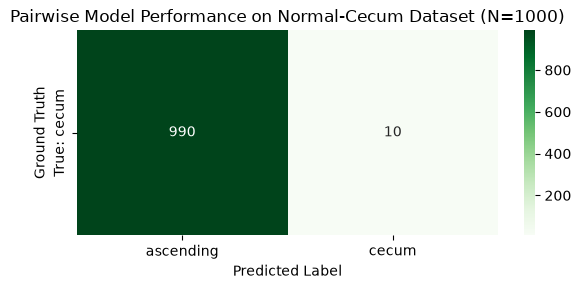

In [1]:
from collections import Counter
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. Define paths for the pairwise model and dataset
PAIRWISE_WEIGHTS_PATH = r"D:\Marina\Nebras_RandD\runs\classify\vim_polyp_pairwise\results\cecum_vs_ascending-3\weights\best.pt"  # Update this!
DATASET_PATH = r"D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum"

# 2. Check if weights file exists
if not os.path.exists(PAIRWISE_WEIGHTS_PATH):
    raise FileNotFoundError(
        f"Weights file not found at: {PAIRWISE_WEIGHTS_PATH}\n"
        "Please update `PAIRWISE_WEIGHTS_PATH` with the correct path to your binary model."
    )

# 3. Load the pairwise model
model = YOLO(PAIRWISE_WEIGHTS_PATH)

print("=" * 50)
print(f"Model Loaded. Classes: {model.names}")
print("=" * 50)

# 4. Run Inference (Note: imgsz=224 matches training resolution)
print("\n--- Running Pairwise Prediction ---")
results = model.predict(
    source=DATASET_PATH,
    imgsz=224,  # Matching 224x224 training resolution
    conf=0.25,
    save=True,
    project=r"D:\Marina\Nebras_RandD\runs\classify\kvasir_evaluation",
    name="pairwise_cecum_vs_ascending",
)

# 5. Extract Predictions
predictions = []
for result in results:
    top_class_id = result.probs.top1
    predicted_class_name = result.names[top_class_id]
    predictions.append(predicted_class_name)

# 6. Analyze Breakdown
pred_counts = Counter(predictions)
total_images = len(results)
all_classes = sorted(list(model.names.values()))

print("\n" + "=" * 50)
print(f"PAIRWISE BREAKDOWN FOR {total_images} 'NORMAL-CECUM' IMAGES")
print("=" * 50)

for cls_name in all_classes:
    count = pred_counts.get(cls_name, 0)
    pct = (count / total_images) * 100
    print(f"Predicted as '{cls_name}': {count:4d} / {total_images} ({pct:.2f}%)")

# Determine accuracy assuming ground truth is 'cecum' (or matching case)
cecum_key = next(
    (cls for cls in all_classes if "cecum" in cls.lower()), "cecum"
)
correct_cecum = pred_counts.get(cecum_key, 0)
accuracy = (correct_cecum / total_images) * 100

print("-" * 50)
print(
    f"Accuracy on Cecum folder: {accuracy:.2f}% ({correct_cecum}/{total_images} correct)"
)
print("=" * 50)

# 7. Plot Binary Confusion Matrix
cm_row = [pred_counts.get(cls, 0) for cls in all_classes]

plt.figure(figsize=(6, 3))
sns.heatmap(
    [cm_row],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=all_classes,
    yticklabels=["True: cecum"],
    cbar=True,
)

plt.title(
    f"Pairwise Model Performance on Normal-Cecum Dataset (N={total_images})"
)
plt.xlabel("Predicted Label")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

C3VD\cecum_t1_a

Found 276 color images ending with '_color.png' in D:\Marina\C3VD\cecum_t1_a

--- Running Prediction on C3VD Color Images ---

PREDICTION BREAKDOWN FOR C3VD CECUM_T1_A (276 IMAGES)
Predicted as 'ascending':   40 / 276 (14.49%)
Predicted as 'cecum':    0 / 276 (0.00%)
Predicted as 'descending':   62 / 276 (22.46%)
Predicted as 'hepaticflexure':   11 / 276 (3.99%)
Predicted as 'rectum':   32 / 276 (11.59%)
Predicted as 'sigmoid':  131 / 276 (47.46%)
Predicted as 'splenicflexure':    0 / 276 (0.00%)
Predicted as 'transverse':    0 / 276 (0.00%)
--------------------------------------------------
Accuracy on C3VD Cecum folder: 0.00% (0/276 correct)


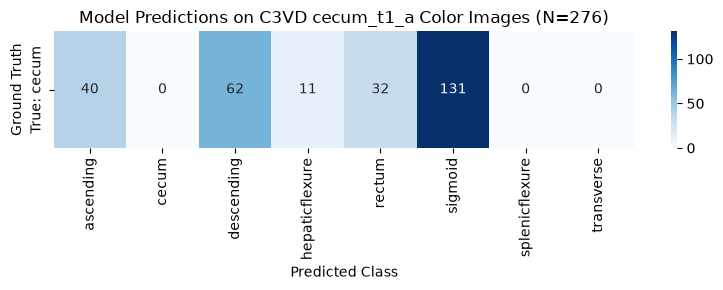

In [10]:
from collections import Counter
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. Define paths
WEIGHTS_PATH = r"D:\Marina\Nebras_RandD\runs\classify\vim_polyp_yolo\results\exp1_baseline\weights\best.pt"  # Or your pairwise model path
C3VD_FOLDER = r"D:\Marina\C3VD\cecum_t1_a"

# 2. Check path & filter for files ending with '_color.png'
color_images = glob.glob(os.path.join(C3VD_FOLDER, "*_color.png"))

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(f"Weights file not found at: {WEIGHTS_PATH}")

if len(color_images) == 0:
    # If images are inside a nested subfolder (e.g., cecum_t1_a/color/ or cecum_t1_a/rgb/)
    color_images = glob.glob(
        os.path.join(C3VD_FOLDER, "**", "*_color.png"), recursive=True
    )

print(
    f"Found {len(color_images)} color images ending with '_color.png' in {C3VD_FOLDER}"
)

if len(color_images) == 0:
    raise FileNotFoundError(
        "No files ending with '_color.png' were found. Please check your folder structure."
    )

# 3. Load model
model = YOLO(WEIGHTS_PATH)

# 4. Run Inference (matching training resolution imgsz=224)
print("\n--- Running Prediction on C3VD Color Images ---")
results = model.predict(
    source=color_images,  # Pass the explicit list of color image paths
    imgsz=224,  # Use 224x224 matching training resolution
    conf=0.25,
    save=True,
    project=r"D:\Marina\Nebras_RandD\runs\classify\c3vd_evaluation",
    name="cecum_t1_a_color_preds",
)

# 5. Extract Predictions
predictions = []
for result in results:
    top_class_id = result.probs.top1
    predicted_class_name = result.names[top_class_id]
    predictions.append(predicted_class_name)

# 6. Prediction Breakdown Analysis
total_images = len(results)
pred_counts = Counter(predictions)
all_classes = sorted(list(model.names.values()))

print("\n" + "=" * 50)
print(f"PREDICTION BREAKDOWN FOR C3VD CECUM_T1_A ({total_images} IMAGES)")
print("=" * 50)

for cls_name in all_classes:
    count = pred_counts.get(cls_name, 0)
    pct = (count / total_images) * 100
    print(f"Predicted as '{cls_name}': {count:4d} / {total_images} ({pct:.2f}%)")

# Determine accuracy assuming true anatomical region is 'cecum'
cecum_key = next(
    (cls for cls in all_classes if "cecum" in cls.lower()), "cecum"
)
correct_cecum = pred_counts.get(cecum_key, 0)
accuracy = (correct_cecum / total_images) * 100

print("-" * 50)
print(
    f"Accuracy on C3VD Cecum folder: {accuracy:.2f}% ({correct_cecum}/{total_images} correct)"
)
print("=" * 50)

# 7. Plot Prediction Distribution
cm_row = [pred_counts.get(cls, 0) for cls in all_classes]

plt.figure(figsize=(8, 3))
sns.heatmap(
    [cm_row],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=all_classes,
    yticklabels=["True: cecum"],
    cbar=True,
)

plt.title(f"Model Predictions on C3VD cecum_t1_a Color Images (N={total_images})")
plt.xlabel("Predicted Class")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()